In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, ArrayType, MapType
import pandas as pd


In [4]:
import sys
import os
import time
# Add the src/ directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src/")))

In [5]:
# Check if there's an active Spark context and stop it
from pyspark import SparkContext
if SparkContext._active_spark_context:
    print("Stopping existing Spark context...")
    SparkContext._active_spark_context.stop()
    print("Previous Spark context stopped successfully")

In [6]:
# Set environment variables
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

# Create new session with explicit local binding
spark = SparkSession.builder \
    .appName("EEG_Analysis") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.host", "127.0.0.1") \
    .master("local[*]") \
    .getOrCreate()

print("New Spark session created successfully")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/05 18:23:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


New Spark session created successfully


25/04/05 18:23:29 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [7]:
spark = SparkSession.builder.appName("MyApp").getOrCreate()


25/04/05 18:23:29 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [8]:
from populate_schemas import load_subjects_df, extract_features_udtf
from feature_extraction import processEpoch, processSub
from schema_definition import get_feature_schema, get_subject_schema


# from feature_extraction

In [9]:
# preprocess_sets.setProjectRootDir()
subject_df = load_subjects_df(spark)


In [10]:
ROOT_DIR = ".."
SRC_DIR = ROOT_DIR + "/src"

In [11]:
sc = spark.sparkContext
# Add all necessary modules
try:
    sc.addPyFile(os.path.join(SRC_DIR, "feature_extraction.py"))
    print("Added feature_extraction.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "preprocess_sets.py"))
    print("Added preprocess_sets to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "schema_definition.py"))
    print("Added schema_definition.py to the pyspark context")
except Exception as e:
    print(f"Error adding files to SparkContext: {e}")

Added feature_extraction.py to the pyspark context
Added preprocess_sets to the pyspark context
Added schema_definition.py to the pyspark context


In [12]:
%%time
result = (
    subject_df
    .filter((subject_df.SubjectID == "sub-001"))
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)
result.show()

/Users/admin/neuro-venv/lib/python3.9/site-packages/pyspark/sql/pandas/group_ops.py:104: UserWarning: It is preferred to use 'applyInPandas' over this API. This API will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(
function ran                                                        (0 + 1) / 1]
Processing subject sub-001
processSub sub-001
subPath sub-001
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set
Got 398 epochs for sub-001
<class 'mne.epochs.Epochs'>
Epoch 0
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
Epoch 1
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
Total rows collected: 37810
Returning DataFrame with 37810 rows
Column names from schema: ['SubjectID', 'EpochID', 'WaveBand', 'Electrode', 'Power']
4.074887990951538
                                                                                

+---------+-------+--------+---------+--------------------+
|SubjectID|EpochID|WaveBand|Electrode|               Power|
+---------+-------+--------+---------+--------------------+
|  sub-001|   ep-0|   Delta|      Fp1| 0.08257892642542033|
|  sub-001|   ep-0|   Theta|      Fp1|0.005611645685714301|
|  sub-001|   ep-0|   Alpha|      Fp1|0.001143220388171...|
|  sub-001|   ep-0|    Beta|      Fp1|1.958040080323613...|
|  sub-001|   ep-0|   Total|      Fp1|0.011235955056179773|
|  sub-001|   ep-0|   Delta|      Fp2| 0.08389220643958975|
|  sub-001|   ep-0|   Theta|      Fp2|0.004672355992737972|
|  sub-001|   ep-0|   Alpha|      Fp2|9.638188967593915E-4|
|  sub-001|   ep-0|    Beta|      Fp2|1.768820461211869...|
|  sub-001|   ep-0|   Total|      Fp2|0.011235955056179771|
|  sub-001|   ep-0|   Delta|       F3| 0.08212274846138015|
|  sub-001|   ep-0|   Theta|       F3|0.005595318986261473|
|  sub-001|   ep-0|   Alpha|       F3|0.001112336388491...|
|  sub-001|   ep-0|    Beta|       F3|2.

In [13]:
%%time
# Start both groups processing (lazy evaluation means these won't execute yet)
result_group_a = (
    subject_df
    .filter(subject_df.Group == "A")
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)

result_group_c = (
    subject_df
    .filter(subject_df.Group == "C")
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)

# Force execution of both by calling an action on each
# This launches both jobs in parallel
from pyspark.sql import functions as F

# Use persist to cache the results in memory
result_group_a = result_group_a.persist()
result_group_c = result_group_c.persist()

# Trigger execution with actions
count_a = result_group_a.count()
count_c = result_group_c.count()

print(f"Processed {count_a} records for Alzheimer's group")
print(f"Processed {count_c} records for Control group")

function ran==========================================>        (168 + 10) / 200]
Processing subject sub-017
processSub sub-017
function ran
Processing subject sub-012
processSub sub-012
function ran
Processing subject sub-020
processSub sub-020
function ran
Processing subject sub-021
processSub sub-021
function ran
Processing subject sub-001
processSub sub-001
function ran
Processing subject sub-016
processSub sub-016
function ran
Processing subject sub-011
processSub sub-011
function ran
Processing subject sub-002
processSub sub-002
function ran
Processing subject sub-018
processSub sub-018
function ran
Processing subject sub-029
processSub sub-029
subPath sub-017
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-017/eeg/sub-017_task-eyesclosed_eeg.set
subPath sub-012
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-012/eeg/sub-012_task-eyesclosed_eeg.set
subPath sub-020
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-020/eeg/sub-020_task-eyesclosed_eeg.set
subPath sub-011
Pa

Processed 1856870 records for Alzheimer's group
Processed 1543465 records for Control group
CPU times: user 318 ms, sys: 192 ms, total: 511 ms
Wall time: 4min 6s


In [14]:
result_group_a.show

<bound method DataFrame.show of DataFrame[SubjectID: string, EpochID: string, WaveBand: string, Electrode: string, Power: double]>

In [80]:
result_group_a.show(2)

+---------+-------+--------+---------+--------------------+
|SubjectID|EpochID|WaveBand|Electrode|               Power|
+---------+-------+--------+---------+--------------------+
|  sub-020|   ep-0|   Delta|      Fp1| 0.07823378995458571|
|  sub-020|   ep-0|   Theta|      Fp1|0.006522342449441742|
+---------+-------+--------+---------+--------------------+
only showing top 2 rows



In [366]:
from pyspark.sql.functions import col, mean as _mean, stddev as _stddev, broadcast
from pyspark.sql.types import FloatType

# Step 1: Convert Power to float32
result_group_a = result_group_a.withColumn("Power", col("Power").cast(FloatType()))
result_group_c = result_group_c.withColumn("Power", col("Power").cast(FloatType()))
result_group_a = result_group_c.withColumn("label", lit(1))
result_group_c = result_group_c.withColumn("label", lit(0))

In [367]:
# Step 2: Compute mean and std from result_group_a only * added union
full_df = result_group_a.union(result_group_c)
norm_stats = full_df.groupBy("Electrode", "WaveBand").agg(
    _mean("Power").alias("mean_power"),
    _stddev("Power").alias("std_power")
)

In [368]:
norm_stats.head(3)

[Row(Electrode='T5', WaveBand='Alpha', mean_power=0.0077667721822678795, std_power=0.008222166213354205),
 Row(Electrode='Pz', WaveBand='Alpha', mean_power=0.004207893557723609, std_power=0.00466346408516268),
 Row(Electrode='F4', WaveBand='Delta', mean_power=0.07940302876485146, std_power=0.00857590563430042)]

In [369]:
# Step 3: Broadcast join stats to both result_group_a and result_group_c
full_df = full_df.join(
    broadcast(norm_stats), on=["Electrode", "WaveBand"]
)


In [370]:
full_df.head(3)

[Row(Electrode='Fp1', WaveBand='Delta', SubjectID='sub-058', EpochID='ep-0', Power=0.07592873275279999, label=1, mean_power=0.07858151282064767, std_power=0.009013420624358148),
 Row(Electrode='Fp1', WaveBand='Theta', SubjectID='sub-058', EpochID='ep-0', Power=0.005362427793443203, label=1, mean_power=0.005025204725375611, std_power=0.003792554646271281),
 Row(Electrode='Fp1', WaveBand='Alpha', SubjectID='sub-058', EpochID='ep-0', Power=0.004296598024666309, label=1, mean_power=0.0033346605650596984, std_power=0.00359142751870947)]

In [371]:
from pyspark.sql.functions import when

full_df_norm = full_df.withColumn(
    "Power",
    (col("Power") - col("mean_power")) /
    when((col("std_power").isNotNull()) & (col("std_power") != 0), col("std_power")).otherwise(1.0) #this otherwise sets std to 1 and since std is 0 mean_power - power = 0
)



In [372]:
# Step 5 (optional): Drop extra columns
full_df_norm = full_df_norm.drop("mean_power", "std_power")

In [373]:
full_df_norm.show(10)

+---------+--------+---------+-------+--------------------+-----+
|Electrode|WaveBand|SubjectID|EpochID|               Power|label|
+---------+--------+---------+-------+--------------------+-----+
|      Fp1|   Delta|  sub-058|   ep-0| -0.2943144648856977|    1|
|      Fp1|   Theta|  sub-058|   ep-0| 0.08891712830008625|    1|
|      Fp1|   Alpha|  sub-058|   ep-0|  0.2678426488061967|    1|
|      Fp1|    Beta|  sub-058|   ep-0| 0.39962084349847926|    1|
|      Fp1|   Total|  sub-058|   ep-0|                 0.0|    1|
|      Fp2|   Delta|  sub-058|   ep-0|-0.29408203039836733|    1|
|      Fp2|   Theta|  sub-058|   ep-0| 0.16916023250174247|    1|
|      Fp2|   Alpha|  sub-058|   ep-0| 0.15175765243674336|    1|
|      Fp2|    Beta|  sub-058|   ep-0| 0.43853448293520503|    1|
|      Fp2|   Total|  sub-058|   ep-0|                 0.0|    1|
+---------+--------+---------+-------+--------------------+-----+
only showing top 10 rows



In [376]:
from pyspark.sql.functions import concat_ws

full_df_norm = full_df_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)

In [377]:
full_df_norm.filter((col("Electrode") == "F3") & (col("WaveBand") == "Total")).show()


+---------+--------+---------+-------+-----+-----+------------------+
|Electrode|WaveBand|SubjectID|EpochID|Power|label|Electrode_WaveBand|
+---------+--------+---------+-------+-----+-----+------------------+
|       F3|   Total|  sub-058|   ep-0|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-058|   ep-1|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-058|   ep-2|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-058|   ep-3|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-058|   ep-4|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-058|   ep-5|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-058|   ep-6|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-058|   ep-7|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-058|   ep-8|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-058|   ep-9|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-058|  ep-10|  0.0|    1|          F3_Total|
|       F3|   Total|

In [378]:
pivot_keys = [row["Electrode_WaveBand"] for row in full_df_norm.select("Electrode_WaveBand").distinct().collect()]

In [379]:
pivot_keys[:4]

['T4_Beta', 'Fp2_Beta', 'P3_Alpha', 'O2_Alpha']

In [380]:
features_df = (
    full_df_norm
    .groupBy("SubjectID", "EpochID", "label")
    .pivot("Electrode_WaveBand", pivot_keys)
    .agg({"Power": "first"})  # Or "avg", depending on your use case
)


In [381]:
features_df.head(1)

[Row(SubjectID='sub-037', EpochID='ep-158', label=1, T4_Beta=-0.8435888074686074, Fp2_Beta=-0.8175003492789749, P3_Alpha=-0.00038772635111502775, O2_Alpha=-0.17793990160663756, T3_Delta=1.0891985935456447, F7_Delta=1.0443106549552088, F8_Beta=-0.8360314943101042, T4_Alpha=-0.7571141499672668, F3_Delta=1.0134449587962036, P4_Theta=-0.7956534232705117, T3_Beta=-0.8396759088361913, F7_Theta=-0.9784239805255148, T5_Theta=-0.8176283732267623, P4_Alpha=0.0980378248865304, T6_Alpha=-0.39027291752729487, Cz_Alpha=-0.5507899364428775, T5_Alpha=-0.2088009314367443, Cz_Delta=0.9101550152914328, F4_Alpha=-0.8131631442127836, Pz_Beta=-0.788651733813285, Fp1_Total=0.0, F4_Theta=-1.0160383305140317, O2_Beta=-0.9393741070813727, O1_Beta=-0.8570542236731797, Pz_Total=0.0, Pz_Alpha=0.3257222085082362, Fp2_Alpha=-0.7984399454698109, O1_Delta=0.30102023795515853, C3_Theta=-1.0701688038702615, Cz_Theta=-0.9667101230723538, T5_Total=0.0, C4_Alpha=-0.5311166612878643, Cz_Total=0.0, T4_Total=0.0, P3_Total=0.0

In [386]:
from pyspark.ml.feature import VectorAssembler

# remove 'SubjectID' from the feature list
feature_cols = [col for col in features_df.columns if col not in ("SubjectID", "EpochID", "label")]
# feature_cols = [col for col in features_df.columns if (col != "SubjectID")]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
# assembled_df = assembler.transform(features_df).select("SubjectID", "EpochID", "features")
assembled_df = assembler.transform(features_df).select("SubjectID", "EpochID", "label", "features")

In [393]:
feature_cols[:4]
"label" in feature_cols

False

In [394]:
assembled_df.columns

['SubjectID', 'EpochID', 'label', 'features']

In [395]:
assembled_df.head(2)

[Row(SubjectID='sub-037', EpochID='ep-158', label=1, features=DenseVector([-0.8436, -0.8175, -0.0004, -0.1779, 1.0892, 1.0443, -0.836, -0.7571, 1.0134, -0.7957, -0.8397, -0.9784, -0.8176, 0.098, -0.3903, -0.5508, -0.2088, 0.9102, -0.8132, -0.7887, 0.0, -1.016, -0.9394, -0.8571, 0.0, 0.3257, -0.7984, 0.301, -1.0702, -0.9667, 0.0, -0.5311, 0.0, 0.0, 0.0, 1.012, 1.0975, -0.6783, 0.0, 0.0, -0.8275, 0.9691, 0.0, 0.2281, -0.7002, 1.0813, 0.0, -0.8447, -1.0584, 0.4015, 0.6315, -0.8104, -0.7131, 0.5423, 0.0, -0.9604, 0.0, -0.717, 0.7873, -0.7813, 1.1472, 0.0, -0.7712, 0.0, -0.7306, -0.7131, 0.0, -1.0749, 0.0, -0.9967, 0.6149, 1.0447, -0.924, -0.9891, 0.9719, -0.745, -0.9173, -0.7908, -0.7783, 0.0, -0.7592, -1.086, -0.5701, 0.0, -0.7318, -0.7917, 0.0, -0.9231, -0.8088, 1.0831, -1.0246, -0.8371, 0.673, -0.7896, -0.6786])),
 Row(SubjectID='sub-037', EpochID='ep-185', label=1, features=DenseVector([-0.5603, -0.4751, -0.5983, -0.3122, 0.1083, 0.2535, -0.5546, -0.5843, 0.2833, -0.0054, -0.3573, -0.1

In [396]:
from pyspark.ml.feature import PCA

pca = PCA(k=20, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_df)
pca_result = pca_model.transform(assembled_df)

In [397]:
explained_variance = pca_model.explainedVariance.toArray()

In [398]:
explained_variance

array([0.11271299, 0.10877911, 0.09445849, 0.08694585, 0.07891233,
       0.05594196, 0.05107735, 0.04924938, 0.04166106, 0.04081108,
       0.03966149, 0.03512126, 0.03345499, 0.02969315, 0.02610939,
       0.02362075, 0.01970582, 0.01681308, 0.01565166, 0.01409203])

In [399]:
sum(explained_variance[:8])

np.float64(0.6380774716904251)

In [400]:
sum(explained_variance[:11])

np.float64(0.760211102468542)

In [401]:
sum(explained_variance[:18])

np.float64(0.9447295493494149)

In [402]:
assembled_df.printSchema()

root
 |-- SubjectID: string (nullable = false)
 |-- EpochID: string (nullable = false)
 |-- label: integer (nullable = false)
 |-- features: vector (nullable = true)



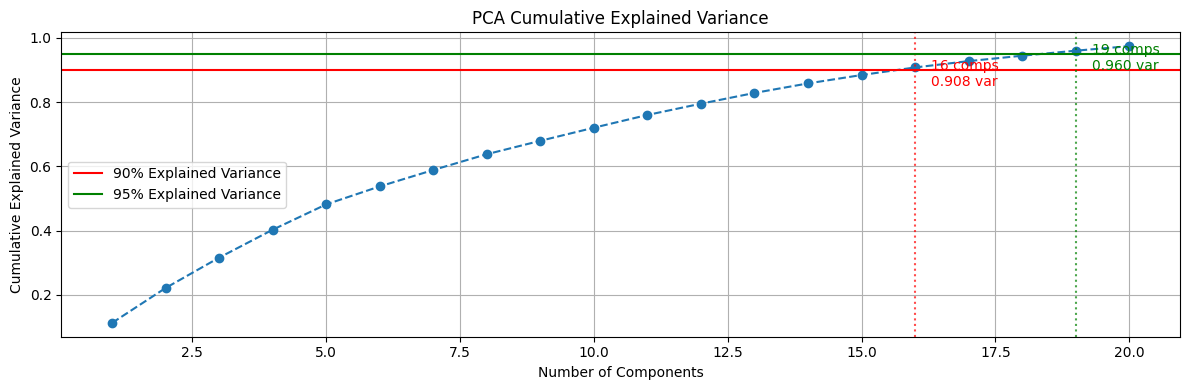

In [403]:
import matplotlib.pyplot as plt
import numpy as np

# Get the variance values from PySpark
explained_variance = pca_model.explainedVariance.toArray()
cumulative_variance = np.cumsum(explained_variance)

# Find component index where thresholds are reached
thresholds = [0.90, 0.95]
threshold_indices = [np.argmax(cumulative_variance >= t) for t in thresholds]

# Plot
plt.figure(figsize=(12, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

# Draw horizontal and vertical lines at thresholds
colors = ['r', 'g']
for idx, t in zip(threshold_indices, thresholds):
    comp_number = idx + 1
    cum_var = cumulative_variance[idx]

    # Horizontal line
    plt.axhline(y=t, color=colors[thresholds.index(t)], linestyle='-', label=f'{int(t*100)}% Explained Variance')
    # Vertical line
    plt.axvline(x=comp_number, color=colors[thresholds.index(t)], linestyle=':', alpha=0.7)
    # Annotation
    plt.text(comp_number + 0.3, t - 0.05, f'{comp_number} comps\n{cum_var:.3f} var', color=colors[thresholds.index(t)])

# Labels & Legend
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Doing pyspark ML

In [415]:
from pyspark.sql.functions import lit

# Add label column (0 = Group A, 1 = Group C)
result_group_a_norm = result_group_a_norm.withColumn("label", lit(1))
result_group_c_norm = result_group_c_norm.withColumn("label", lit(0))

print("Columns in result_group_a_norm:")
print(result_group_a_norm.columns)

print("\nColumns in result_group_c_norm:")
print(result_group_c_norm.columns)

Columns in result_group_a_norm:
['Electrode', 'WaveBand', 'SubjectID', 'EpochID', 'Power', 'Electrode_WaveBand', 'label']

Columns in result_group_c_norm:
['Electrode', 'WaveBand', 'SubjectID', 'EpochID', 'Power', 'Electrode_WaveBand', 'label']


In [404]:
from pyspark.ml.feature import PCA

# Try a high number first (e.g., all features)
k_max = len(feature_cols)
pca_model = PCA(k=k_max, inputCol="features", outputCol="pca_features").fit(assembled_df)

# Get explained variance and find smallest k with >= 0.95 cumulative
import numpy as np

vairance_goal = 0.95

explained_variance = np.cumsum(pca_model.explainedVariance.toArray())
k_val = np.argmax(explained_variance >= vairance_goal) + 1  # +1 because index starts at 0
print(f"Using top {k_val} components to explain {vairance_goal}% variance")


Using top 19 components to explain 0.95% variance


In [405]:
assembled_df.head()

Row(SubjectID='sub-037', EpochID='ep-158', label=1, features=DenseVector([-0.8436, -0.8175, -0.0004, -0.1779, 1.0892, 1.0443, -0.836, -0.7571, 1.0134, -0.7957, -0.8397, -0.9784, -0.8176, 0.098, -0.3903, -0.5508, -0.2088, 0.9102, -0.8132, -0.7887, 0.0, -1.016, -0.9394, -0.8571, 0.0, 0.3257, -0.7984, 0.301, -1.0702, -0.9667, 0.0, -0.5311, 0.0, 0.0, 0.0, 1.012, 1.0975, -0.6783, 0.0, 0.0, -0.8275, 0.9691, 0.0, 0.2281, -0.7002, 1.0813, 0.0, -0.8447, -1.0584, 0.4015, 0.6315, -0.8104, -0.7131, 0.5423, 0.0, -0.9604, 0.0, -0.717, 0.7873, -0.7813, 1.1472, 0.0, -0.7712, 0.0, -0.7306, -0.7131, 0.0, -1.0749, 0.0, -0.9967, 0.6149, 1.0447, -0.924, -0.9891, 0.9719, -0.745, -0.9173, -0.7908, -0.7783, 0.0, -0.7592, -1.086, -0.5701, 0.0, -0.7318, -0.7917, 0.0, -0.9231, -0.8088, 1.0831, -1.0246, -0.8371, 0.673, -0.7896, -0.6786]))

In [406]:
pca = PCA(k=k_val, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_df)
pca_result = pca_model.transform(assembled_df)


In [409]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

# Turn vector into individual PC columns
pca_result = pca_result.withColumn("pca_array", vector_to_array("pca_features"))

# Select label + principal components
for i in range(k_val):
    pca_result = pca_result.withColumn(f"PC{i+1}", col("pca_array")[i])

# Final dataframe with PCs
full_df = pca_result.select("SubjectID", "EpochID", "label", *[f"PC{i+1}" for i in range(k_val)])


In [411]:
from pyspark.ml.feature import VectorAssembler

pca_cols = [col for col in full_df.columns if col.startswith("PC")]
assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
assembled_df = assembler.transform(full_df).select("features", "label")

In [412]:
# Step 1: Get distinct subject IDs from each group
group_a_subjects = (
    full_df.filter(full_df["label"] == 0)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)

group_c_subjects = (
    full_df.filter(full_df["label"] == 1)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)

# Step 2: Get the last 3 subjects from each group for testing
test_subjects = group_a_subjects[-3:] + group_c_subjects[-3:]

# Step 3: Filter the full_df to split into train and test based on SubjectID
train_df = full_df.filter(~full_df.SubjectID.isin(test_subjects))
test_df = full_df.filter(full_df.SubjectID.isin(test_subjects))


In [413]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
train_df = assembler.transform(train_df).select("features", "label")
test_df = assembler.transform(test_df).select("features", "label")

from pyspark.sql.types import IntegerType
train_df = train_df.withColumn("label", train_df["label"].cast(IntegerType()))

In [414]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Get input size from PCA features
input_dim = len(pca_cols)

mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_dim, 100, 2],  # input → hidden (100 units) → 2 output classes
    maxIter=1000,
    seed=42
)

mlp_model = mlp.fit(train_df)
mlp_preds = mlp_model.transform(test_df)


[Stage 14672:==============>                                       (3 + 8) / 11]

# WHY TF IS IT GETTING DIFFERNET EXPLAINED VARIENCES

# Using the functions created to normalize

In [15]:
from dimensionality_reduction import normalize_power

In [16]:
df_a_norm, df_c_norm = normalize_power(result_group_a, result_group_c)

In [18]:
df_a_norm.show(30)

+---------+--------+---------+-------+--------------------+
|Electrode|WaveBand|SubjectID|EpochID|               Power|
+---------+--------+---------+-------+--------------------+
|      Fp1|   Delta|  sub-020|   ep-0|-0.22287221524788234|
|      Fp1|   Theta|  sub-020|   ep-0| 0.23452256993451262|
|      Fp1|   Alpha|  sub-020|   ep-0|   0.652996502786586|
|      Fp1|    Beta|  sub-020|   ep-0| -0.3898200899055782|
|      Fp1|   Total|  sub-020|   ep-0|                 0.0|
|      Fp2|   Delta|  sub-020|   ep-0|-0.27248447938609727|
|      Fp2|   Theta|  sub-020|   ep-0|  0.3297128332901876|
|      Fp2|   Alpha|  sub-020|   ep-0| 0.45484677266657936|
|      Fp2|    Beta|  sub-020|   ep-0|-0.19059251944965738|
|      Fp2|   Total|  sub-020|   ep-0|                 0.0|
|       F3|   Delta|  sub-020|   ep-0| 0.06729569195896423|
|       F3|   Theta|  sub-020|   ep-0|-0.13344110219088656|
|       F3|   Alpha|  sub-020|   ep-0| 0.14764310589818766|
|       F3|    Beta|  sub-020|   ep-0|-0

In [79]:
import pickle

# Convert to Pandas first
df_a_pd = df_a_norm.toPandas()

df_a_pd.to_pickle("eeg_features_alz_pygrnd6.pkl")
# Save to a pickle file


In [19]:
# put the label for the dataframes
from pyspark.sql.functions import lit
df_a = df_a_norm.withColumn("label", lit(1))
df_c = df_c_norm.withColumn("label", lit(0))
full_df = df_a.union(df_c)

In [20]:
# splitting training and testing


group_a_subjects = (
    full_df.filter(full_df["label"] == 0)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)

group_c_subjects = (
    full_df.filter(full_df["label"] == 1)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)


test_subjects = group_a_subjects[-3:] + group_c_subjects[-3:]

# Filter the full_df to split into train and test based on SubjectID
train_df = full_df.filter(~full_df.SubjectID.isin(test_subjects))
test_df = full_df.filter(full_df.SubjectID.isin(test_subjects))

In [21]:
import dimensionality_reduction

In [22]:
from dimensionality_reduction import prepare_features_for_pca, fit_pca_model, apply_pca_model

In [23]:
#  prepare features for PCA

from dimensionality_reduction import prepare_features_for_pca
train_feat_df, feature_cols = prepare_features_for_pca(train_df)
test_feat_df, _ = prepare_features_for_pca(test_df)

In [26]:
pca_model, k = fit_pca_model(train_feat_df, feature_cols, variance_target=0.95)

# TODO: getting different number of PCA values then playground 4 and 5  so ? Maybe check difference between dataframes if they are different  

In [54]:
k

20

In [55]:
pca_model.explainedVariance.toArray()

array([0.10395404, 0.09881219, 0.09020643, 0.07630289, 0.07345073,
       0.06325665, 0.05846561, 0.05142891, 0.0469734 , 0.0441241 ,
       0.03620411, 0.0345958 , 0.03207046, 0.0291238 , 0.02520649,
       0.02271144, 0.02102785, 0.01968885, 0.01458948, 0.01431236])

In [56]:
sum( pca_model.explainedVariance.toArray())

np.float64(0.9565055762312851)

In [57]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [c for c in train_feat_df.columns if c not in ("SubjectID", "EpochID", "label")]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_train_df = assembler.transform(train_feat_df)

from pyspark.ml.feature import PCA

pca = PCA(k=20, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_train_df)
pca_result = pca_model.transform(assembled_train_df)

In [58]:
# Apply the PCA to both sets
train_pca = apply_pca_model(train_feat_df, feature_cols, pca_model, k)
test_pca = apply_pca_model(test_feat_df, feature_cols, pca_model, k)

# this is the ML part to test  

In [70]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import col

# 1. Automatically get PCA feature columns (PC1, PC2, ..., PCk)
pca_cols = [c for c in train_pca.columns if c.startswith("PC")]

In [71]:
# 2. Assemble vector features
assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
train_df_vec = assembler.transform(train_pca).select("features", "label")
test_df_vec = assembler.transform(test_pca).select("features", "label")

In [72]:
# 3. Define the neural network (MLP)
input_dim = len(pca_cols)  # should match number of PCs used
mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_dim, 100, 2],  # input → hidden (100) → output (2 classes)
    maxIter=1000,
    seed=42
)


In [73]:
# 4. Train and predict
mlp_model = mlp.fit(train_df_vec)
mlp_preds = mlp_model.transform(test_df_vec)

# 5. Evaluate results
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(mlp_preds)
print(f"Neural Net Accuracy: {accuracy:.4f}")


Neural Net Accuracy: 0.6196


In [78]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Convert Spark predictions to Pandas
preds_pd = mlp_preds.select("prediction", "label").toPandas()

# Accuracy
print("Neural Network Accuracy:", accuracy_score(preds_pd["label"], preds_pd["prediction"]))

# F1 Score (weighted)
print("Weighted F1 Score:", f1_score(preds_pd["label"], preds_pd["prediction"], average="weighted"))

# Full classification report
target_names = ["Control", "Alzheimer's"]
print(classification_report(preds_pd["label"], preds_pd["prediction"], target_names=target_names))


Neural Network Accuracy: 0.6196066921044907
Weighted F1 Score: 0.6176738501867369
              precision    recall  f1-score   support

     Control       0.64      0.55      0.59      1691
 Alzheimer's       0.61      0.69      0.65      1716

    accuracy                           0.62      3407
   macro avg       0.62      0.62      0.62      3407
weighted avg       0.62      0.62      0.62      3407



In [68]:
train_pca.columns

['SubjectID',
 'EpochID',
 'label',
 'PC1',
 'PC2',
 'PC3',
 'PC4',
 'PC5',
 'PC6',
 'PC7',
 'PC8',
 'PC9',
 'PC10',
 'PC11',
 'PC12',
 'PC13',
 'PC14',
 'PC15',
 'PC16',
 'PC17',
 'PC18',
 'PC19',
 'PC20']

In [69]:
from pyspark.ml.feature import VectorAssembler

pca_cols = [c for c in train_pca.columns if c.startswith("PC")]  # e.g., ["PC1", "PC2", ..., "PC11"]

assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
train_df_vec = assembler.transform(train_df)
test_df_vec = assembler.transform(test_df)

IllegalArgumentException: PC1 does not exist. Available: Electrode, WaveBand, SubjectID, EpochID, Power, label

In [66]:
print([c for c in train_df.columns if c.startswith("PC")])


[]


In [64]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import size

# Convert 'features' vector to an array, then compute size
train_df_vec.withColumn("feature_size", size(vector_to_array("features"))).select("feature_size").distinct().show()


[Stage 455:=======================================>            (300 + 10) / 400]

+------------+
|feature_size|
+------------+
|           0|
+------------+



In [61]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Get input size from PCA features
input_dim = len(feature_cols)

mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_dim, 100, 2],  # input → hidden (100 units) → 2 output classes
    maxIter=1000,
    seed=42
)

mlp_model = mlp.fit(train_df_vec)
mlp_preds = mlp_model.transform(test_df_vec)

25/04/05 19:31:57 WARN BlockManager: Putting block rdd_653_12 failed due to exception java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0].
25/04/05 19:31:57 WARN BlockManager: Block rdd_653_12 could not be removed as it was not found on disk or in memory
25/04/05 19:31:57 WARN BlockManager: Putting block rdd_653_23 failed due to exception java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0].
25/04/05 19:31:57 WARN BlockManager: Block rdd_653_23 could not be removed as it was not found on disk or in memory
25/04/05 19:31:57 WARN BlockManager: Putting block rdd_653_22 failed due to exception java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0].
25/04/05 19:31:57 WARN BlockManager: Block rdd_653_22 could not be removed as it was not found on disk or in memory
25/04/05 19:31:57 ERROR Executor: Exception in task 22.0 in stage 444.0 (TID 12607)
j

Py4JJavaError: An error occurred while calling o1429.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 34 in stage 444.0 failed 1 times, most recent failure: Lost task 34.0 in stage 444.0 (TID 12619) (localhost executor driver): java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0]
	at java.base/java.lang.System.arraycopy(Native Method)
	at org.apache.spark.ml.ann.DataStacker.$anonfun$stack$4(Layer.scala:665)
	at org.apache.spark.ml.ann.DataStacker.$anonfun$stack$4$adapted(Layer.scala:664)
	at scala.collection.immutable.List.foreach(List.scala:431)
	at org.apache.spark.ml.ann.DataStacker.$anonfun$stack$3(Layer.scala:664)
	at scala.collection.Iterator$$anon$10.next(Iterator.scala:461)
	at scala.collection.Iterator$$anon$10.next(Iterator.scala:461)
	at org.apache.spark.storage.memory.MemoryStore.putIterator(MemoryStore.scala:224)
	at org.apache.spark.storage.memory.MemoryStore.putIteratorAsValues(MemoryStore.sca